In [21]:
import numpy as np

heights = [1.83, 1.76, 1.69, 1.77, 1.73]
weights = [85.12, 74.13, 59.13, 80.12, 68.00]
heights = np.array(heights)
weights = np.array(weights)
heights_mean = np.mean(heights).round(2)
weights_mean = np.mean(weights).round(2)
bmi = (weights/(heights**2)).round(2)
bmi_mean = np.mean(bmi).round(2)
print("신규회원들의 키 : {}".format(heights))
print("신규회원들의 평균 키 : {}".format(heights_mean))
print(heights)
print(heights_mean)

print(bmi)
print(bmi_mean)
print(np.sum(bmi >=25),"명")

신규회원들의 키 : [1.83 1.76 1.69 1.77 1.73]
신규회원들의 평균 키 : 1.76
[1.83 1.76 1.69 1.77 1.73]
1.76
[25.42 23.93 20.7  25.57 22.72]
23.67
2 명


In [75]:
import pandas as pd
info = {'이름' : ['박보검','아이유','김선호','이수경','이준영','박해준'],
       '나이' : [33,32,36,25,27,45],
       '신장' : [183,165,180,165,178,180],
       '체중' : [75,55,74,58,72,78],
       '혈액형' : ['A','B','B','O','AB','B']}
df = pd.DataFrame(info)
df.loc[6] = ['김용림',86,162,75,'AB']
df['소속사'] = ['SM','쿠팡','카카오','SM','JYP','SM','무소속']
arr = df.to_numpy()
print("         **폭싹 속았수다 출연진**     ")
for i,k,l,m,n,o in arr : 
    print(i,k,l,m,n,o, sep="\t")
print("======"*10)
blood = df.groupby("혈액형").count()
print("A형 인원수 : ", blood.loc['A']['이름'])
print("B형 인원수 : ", blood.loc['B']['이름'])
print("AB형 인원수 : ", blood.loc['AB']['이름'])
print("O형 인원수 : ", blood.loc['O']['이름'])
print("평균 나이 : ", df['나이'].mean().round(2))
print("평균 신장 : ", df['신장'].mean().round(2))
print("평균 체중 : ", df['체중'].mean().round(2))

         **폭싹 속았수다 출연진**     
박보검	33	183	75	A	SM
아이유	32	165	55	B	쿠팡
김선호	36	180	74	B	카카오
이수경	25	165	58	O	SM
이준영	27	178	72	AB	JYP
박해준	45	180	78	B	SM
김용림	86	162	75	AB	무소속
A형 인원수 :  1
B형 인원수 :  3
AB형 인원수 :  2
O형 인원수 :  1
평균 나이 :  40.57
평균 신장 :  173.29
평균 체중 :  69.57


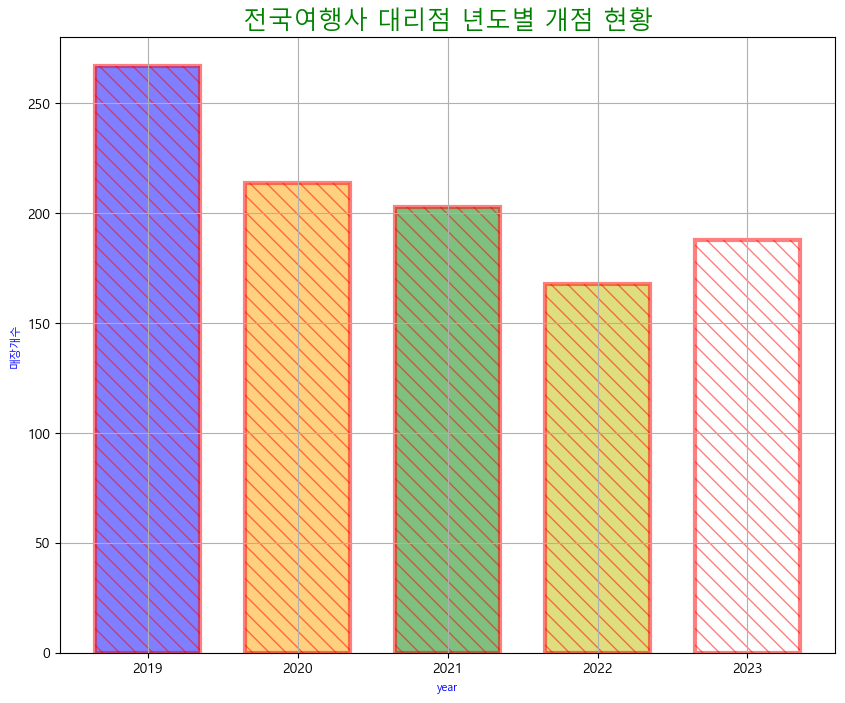

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("./data/travel.csv")
df.dtypes
df.isnull().sum()
df.duplicated().sum()
df[df.duplicated(keep=False)]
df.dropna(subset=['상세영업상태','도로명'], inplace=True)
df.drop_duplicates(keep="first", inplace=True)
df.duplicated().sum()
df['자본금'].describe()
df = df[df['상세영업상태'] == '영업중']
df['상세영업상태'].unique()
df.loc[df['자본금'] >= 30000000, '자본금']=32000000
df['인허가일자']= pd.to_datetime(df['인허가일자'])
df['개점년도'] = df['인허가일자'].dt.year
df.head()
num = df.groupby('개점년도')['사업장명'].nunique()
money = df.groupby('개점년도')['자본금'].sum()
newdf = pd.DataFrame({'사업장명' : num, '자본금' : money})
newdf = newdf.rename(columns = {'사업장명' : '년도별매장개수'})
newdf['순위'] = newdf['년도별매장개수'].rank(method='first', ascending=False).astype(int)
newdf = newdf.sort_values(by='년도별매장개수',ascending=False)
newdf.head()
branch_rank =newdf.loc[(newdf.index > 2018) & (newdf.index <= 2023)]
plt.figure(figsize=(10,8))
plt.rcParams['font.family'] = 'malgun gothic'
plt.title("전국여행사 대리점 년도별 개점 현황", color = "green", fontsize=18)
plt.bar(branch_rank.index,branch_rank['년도별매장개수'],
        color=['blue','orange','g','w','y'], width=0.7, edgecolor='r', linewidth=3, alpha=0.5, hatch='\\\\')
plt.xlabel("year", color = 'b', fontsize=8)
plt.grid()
plt.ylabel("매장개수", color = "b", fontsize=8)
plt.draw()

In [203]:
from bs4 import BeautifulSoup as bs
import requests
import pandas as pd

df = pd.DataFrame()
for page in range(1,2) :
    url = 'https://finance.naver.com/marketindex/exchangeList.naver'
    headers = {'User-Agent' : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36"}
    res = requests.get(url, headers = headers) 
    
    new_data = pd.read_html(res.text,header =0, skiprows=1)[0]
    df = pd.concat([df,new_data], ignore_index = True)
    
df = df.dropna()
df = df.head(10)
df = df.rename(columns = {'통화명' : '국가명', '매매기준율':'환율'})
#df = df[['국가명','환율']]
df

C:\Users\user\AppData\Local\Temp\ipykernel_10280\3327074802.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  new_data = pd.read_html(res.text,header =0, skiprows=1)[0]


,국가명,환율,사실 때,파실 때,보내실 때,받으실 때,미화환산율
0,미국 USD,1366.70,1390.61,1342.79,1380.00,1353.40,1.000
1,유럽연합 EUR,1554.96,1585.90,1524.02,1570.50,1539.42,1.138
2,일본 JPY (100엔),947.29,963.86,930.72,956.57,938.01,0.693
3,중국 CNY,190.10,199.60,180.60,192.00,188.20,0.139
4,홍콩 HKD,174.16,177.59,170.73,175.90,172.42,0.127
6,영국 GBP,1846.96,1883.34,1810.58,1865.42,1828.50,1.351
8,캐나다 CAD,997.26,1016.90,977.62,1007.23,987.29,0.730
9,스위스 CHF,1658.92,1691.60,1626.24,1675.50,1642.34,1.214
10,스웨덴 SEK,142.23,146.92,134.13,143.65,140.81,0.104
11,호주 AUD,886.17,903.62,868.72,895.03,877.31,0.648
